# Investigate interpolation options for boundary contours


## Setup

### Imports

In [ ]:
import logging
from math import isnan

# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *


INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Global Settings

In [ ]:
%matplotlib inline


Boundary scaling should shrink solid regions and expand hollow regions

The boundary scaling does not take into account a hollow centre. As a result, 
when the boundary contour scales the hollow region also shrinks.

See the *Extended Inner Cylinder* example in `StructureDistanceMetricTests.ipynb`

### Extended Inner Cylinder
- Concentric hollow cylinder with an interior cylinder extending beyond the outer cylinder's hole by one slice

![Extended Inner Cylinder](<../../Images/FreeCAD Images/Extended Inner cylinder.png>)


Outer Hollow Cylinder is Disjoint from Inner Cylinder


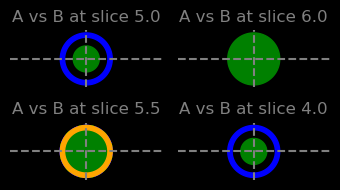

In [10]:
def extended_inner_cylinder_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=12, length=16, offset_z=0,
                                  spacing=slice_spacing,
                                  num_points=100)
    outer_cylinder = make_vertical_cylinder(roi_num=1, radius=6, length=10,
                                            spacing=slice_spacing,
                                            num_points=100)
    cylinder_hole = make_vertical_cylinder(roi_num=1, radius=5, length=10,
                                           spacing=slice_spacing,
                                           num_points=100)
    inner_cylinder = make_vertical_cylinder(roi_num=2, radius=3, length=12,
                                            spacing=slice_spacing,
                                            num_points=100)

    # combine the contours
    slice_data = body + outer_cylinder + cylinder_hole + inner_cylinder
    return slice_data


slice_data = extended_inner_cylinder_example()
structures = StructureSet(slice_data, logging_enabled=False)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
structure_a.name = 'A'
structure_b.name = 'B'
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()
print(f'\nOuter Hollow Cylinder {relation_type.label} Inner Cylinder')

tolerance = 0.01
# Create figure and plot
fig, ax = plt.subplots(2, 2, figsize=(3.5, 2))
slice_idx = 5.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2], add_axis=True, axes=ax[0,0],
               plot_mode='relationship', show_legend=False)
slice_idx = 6.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2], add_axis=True, axes=ax[0,1],
               plot_mode='relationship', show_legend=False)
slice_idx = 5.5
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2], add_axis=True, axes=ax[1,0],
               plot_mode='relationship', show_legend=False)
slice_idx = 4.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2], add_axis=True, axes=ax[1,1],
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()


At the boundary slice (5.5) the outer ring has been reduced to 1/2 its original 
size, but the inner cylinder is not reduced in size because it is not at a 
boundary.

In this case the interpolation of the boundary should have reduced the 
thickness of the ring rather than shrink its diameter.

One way to do this is for each point in the contour (both exterior and hole),
find a line between the exterior and hole at that point and then shift 
the point by 1/4 of the line length.

A key question is: How to establish the direction of the line between the 
exterior and hole?  There are multiple reasonable (and unreasonable) ways to 
establish the direction. Three possible options are:
- Tangent
  - shape is most consistent 
  - line direction is also determined 
  - more complex, possibly slower 
  - Minimum distance
  - simplest calculation 
  - likely to distort shape 
- Centroid (Centre of mass)
- Centre (of bounds)
    - Compromise between simplicity and distortion 
    - centroid vs center is just difference in conversion point.

For the example above, all three methods converge to the same result.
To compare these methods I will need to use non-symmetric contours.

- With a C shape (Cropped ring) The Tangent and Centre will be the same, but 
  the Centroid will be different
- With an oval shape the Centroid and Centre will be the same, but the Tangent 
  will be different.
- A cylinder with two holes will cause the exterior Tangent to match the 
  Centroid and Centre, but the hole Tangents will be different. 
- Using box or triangle shapes will result in the minimum number of point in the 
  contour.  This will test the robustness of the algorithm.